In [469]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns


# Get Data

In [470]:
update_data = False

In [471]:
def get_data(table_name:str, update_data) -> [pd.DataFrame, pd.DataFrame]:
    if update_data:
        experimenter = PyExperimenter(experiment_configuration_file_path="conf/experiment_config.yml",
                                database_credential_file_path="conf/database_credentials.yml",
                                table_name=table_name)
        main_table = experimenter.get_table()
        log_table = experimenter.get_logtable("sh_iterations")

        main_table.to_csv(f"plain_data/{table_name}/table.csv", index=False)
        log_table.to_csv(f"plain_data/{table_name}/logtable.csv", index=False)
    else:
        main_table = pd.read_csv(f"plain_data/{table_name}/table.csv")
        log_table = pd.read_csv(f"plain_data/{table_name}/logtable.csv")

    return main_table, log_table


In [472]:
final_results_table, final_results_logtable = get_data("all_results", update_data)
successive_halving_table, successive_halving_logtable = get_data("successive_halving", update_data)


# Merge DataFrames

In [473]:
def merge_dataframes(main_df: pd.DataFrame, log_df: pd.DataFrame, ) -> pd.DataFrame:
    log_df = log_df.drop(columns=["ID"], errors='ignore')
    return main_df.merge(log_df, left_on="ID", right_on="experiment_id", how="left", suffixes=('_final', '_logtable'))

def subselect_max_budget_entries(merged_df: pd.DataFrame, num_arms:int) -> pd.DataFrame:
    idx = merged_df.groupby('ID')['iteration'].transform(max) == merged_df['iteration']
    merged_df = merged_df[idx]
    merged_df = merged_df[merged_df["num_arms_final"] == num_arms]
    return merged_df

final_results_table = merge_dataframes(final_results_table, final_results_logtable)
final_results_table_lcbench = final_results_table[final_results_table["benchmark"] == "lcbench"]
final_results_table_synthetic = final_results_table[final_results_table["benchmark"] == "synthetic"]
merged_successive_halving = merge_dataframes(successive_halving_table, successive_halving_logtable)

final_results_table = subselect_max_budget_entries(final_results_table, 256)
final_results_table_lcbench = subselect_max_budget_entries(final_results_table_lcbench, 256)
final_results_table_synthetic = subselect_max_budget_entries(final_results_table_synthetic, 256)
merged_successive_halving = subselect_max_budget_entries(merged_successive_halving, 256)
merged_successive_halving_lcbench = merged_successive_halving[merged_successive_halving["benchmark"] == "lcbench"]
merged_successive_halving_synthetic = merged_successive_halving[merged_successive_halving["benchmark"] == "synthetic"]

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_13822/3756739221.py:6: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  idx = merged_df.groupby('ID')['iteration'].transform(max) == merged_df['iteration']


In [474]:
def create_table_summary(merged_df: pd.DataFrame) -> pd.DataFrame:
    return merged_df.groupby("prior").agg(
        avg_consumed_budget=pd.NamedAgg(column="consumed_budget", aggfunc="mean"),
        std_consumed_budget=pd.NamedAgg(column="consumed_budget", aggfunc="std"),
        avg_regret=pd.NamedAgg(column="regret", aggfunc="mean"),
        std_regret=pd.NamedAgg(column="regret", aggfunc="std"),
    ).reset_index()

# Final Results

In [475]:
def final_plots(merged_df: pd.DataFrame, benchmark_name: str, fig_title: str, sigmas:list[float], hue:str = None):
    def create_boxplot(sigma_data,x,y,ax):
        # Set more obvious colors in the plot
        if hue is not None:
            sns.boxplot(data=sigma_data, x=x, y=y, hue=hue, ax=ax, palette="Set2")
        else:
            sns.boxplot(data=sigma_data, x=x, y=y, ax=ax, palette="Set2")

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(fig_title)

    create_boxplot(merged_df, "prior", "regret", ax[0])
    ax[0].set_title(f"Regret Distribution for {benchmark_name}")
    ax[0].set_ylabel("Regret")
    ax[0].set_xlabel("Prior")
    ax[0].set_ylim(0, 0.3)

    # Create boxplot for consumed budget
    create_boxplot(merged_df, "prior", "consumed_budget", ax[1])
    ax[1].set_title(f"Consumed Budget Distribution for {benchmark_name}")
    ax[1].set_ylabel("Consumed Budget")
    ax[1].set_xlabel("Prior")

In [476]:
def rename_priors(df: pd.DataFrame) -> pd.DataFrame:
    rename_dict = {
        "uniform": "Uniform",
        "performance": "Performance",
        "rank": "Rank",
        "inverse_rank": "Inverse Rank",
        "indicator": "Indicator",
    }

    df['prior'] = df['prior'].map(rename_dict).fillna(df['prior'])
    return df

def pareto_front_idea(base_subset: pd.DataFrame):
    sns.set_theme(style="whitegrid", context="talk")
    
    # 1. Rank priors by mean consumed_budget
    ranked_priors = (
        base_subset.groupby("prior")["consumed_budget"]
        .mean()
        .sort_values(ascending=True)
        .index.tolist()
    )
    
    palette = sns.color_palette("colorblind", n_colors=len(ranked_priors))
    fig, ax = plt.subplots(figsize=(8, 5))

    # 2. Iterate using the ranked list
    for i, prior in enumerate(ranked_priors):
        prior_data = base_subset[base_subset["prior"] == prior]
        
        m_reg, s_reg = prior_data["regret"].mean(), prior_data["regret"].sem()
        m_bud, s_bud = prior_data["consumed_budget"].mean(), prior_data["consumed_budget"].sem()
        
        # SWAPPED: m_bud is now X, m_reg is now Y
        ax.errorbar(
            m_bud, m_reg, 
            xerr=s_bud, yerr=s_reg, 
            fmt='o', label=prior,
            color=palette[i],
            markersize=9,
            capsize=3,
            markeredgewidth=0,
            alpha=0.9
        )

    # Updated labels to match swapped axes
    #ax.set_ylim((0, 0.01))
    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("Regret")
    
    # Move legend below the plot
    # ncol puts labels in a row; loc='upper center' with bbox below 0 anchor
    ax.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.28), 
        ncol=3, # Adjust ncol based on your number of priors
        frameon=True
    )
    
    plt.tight_layout()
    
    return fig

In [477]:
def prepare_data(approach_df: pd.DataFrame, baseline_df: pd.DataFrame, use_predicted_y: bool) -> pd.DataFrame:
    approach_df = approach_df[(approach_df["use_predicted_y"] == use_predicted_y)]
    # Add baseline to base_subset
    baseline_df = baseline_df.assign(prior="Standard SH")
    baseline_df["sigma0"] = "Standard SH"  # or another appropriate value
    base_subset = pd.concat([approach_df, baseline_df])
    base_subset = rename_priors(base_subset)
    return base_subset

In [478]:
lcbench_date = prepare_data(final_results_table_lcbench, merged_successive_halving_lcbench, use_predicted_y=False)
synthetic_data = prepare_data(final_results_table_synthetic, merged_successive_halving_synthetic, use_predicted_y=False)

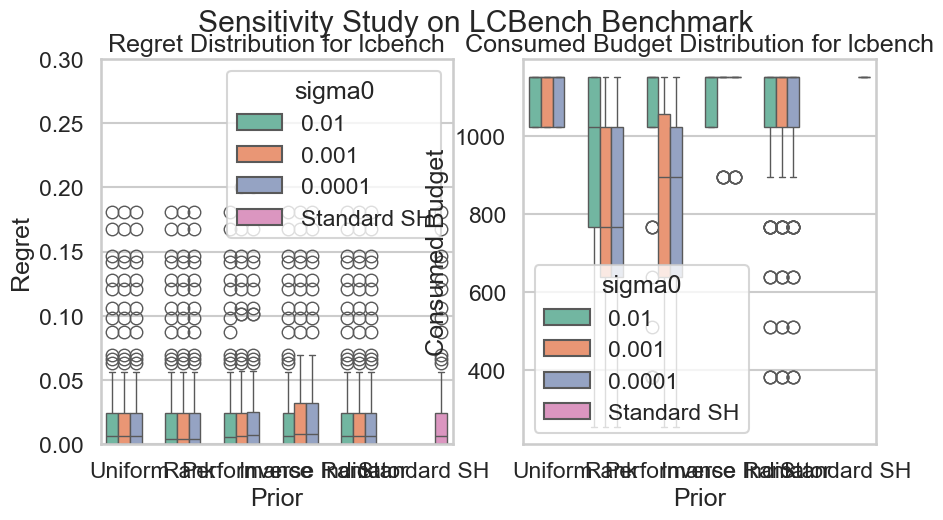

In [479]:
final_plots(lcbench_date, "lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="sigma0")

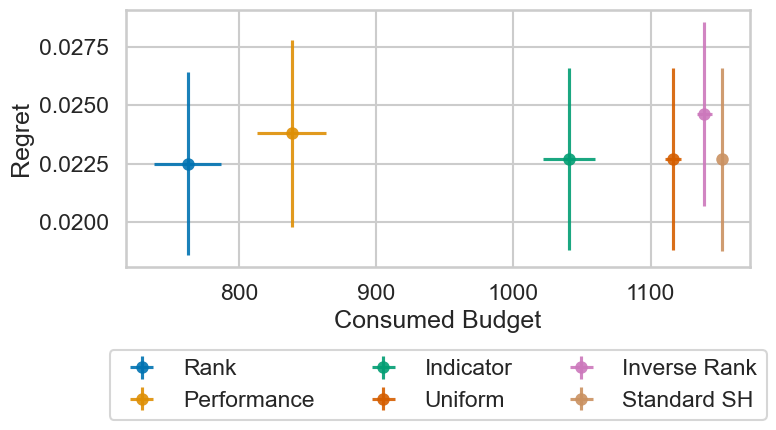

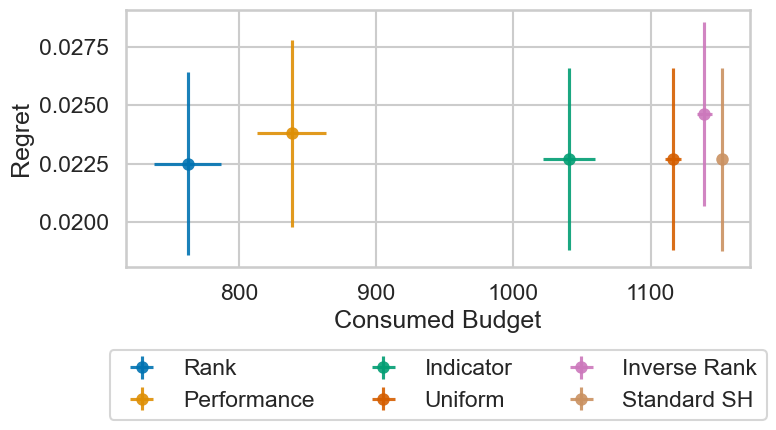

In [480]:
# base subset for pareto front idea
lcbench_date = lcbench_date[(lcbench_date["sigma0"] == 0.0001) | (lcbench_date["prior"] == "Standard SH")]
pareto_front_idea(lcbench_date).savefig("plots/pareto_front_idea_lcbench.pdf", bbox_inches='tight')
pareto_front_idea(lcbench_date).savefig("plots/pareto_front_idea_lcbench.png", bbox_inches='tight')

In [481]:
final_results_table_synthetic["use_predicted_y"].unique()

array([0, 1])

In [482]:
synthetic_data = prepare_data(final_results_table_synthetic, merged_successive_halving_synthetic, use_predicted_y=False)

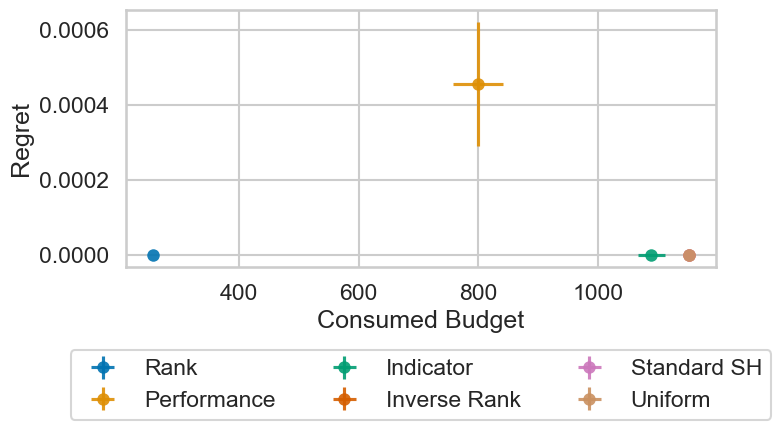

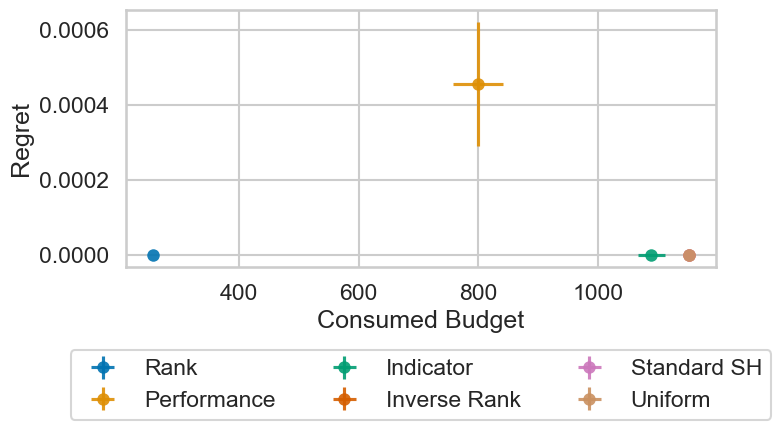

In [483]:
synthetic_data = synthetic_data[((synthetic_data["sigma0"] == 0.0001) & (synthetic_data["kernel"] == "satexp_rbf"))| (synthetic_data["prior"] == "Standard SH")]
pareto_front_idea(synthetic_data).savefig("plots/sensitivity_study_synthetic.pdf", bbox_inches='tight')
pareto_front_idea(synthetic_data).savefig("plots/sensitivity_study_synthetic.png", bbox_inches='tight')